In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/Task 3 and 4_Loan_Data.csv")

In [ ]:
df

,customer_id,credit_lines_outstanding,loan_amt_outstanding,total_debt_outstanding,income,years_employed,fico_score,default
0,8153374,0,5221.545193,3915.471226,78039.38546,5,605,0
1,7442532,5,1958.928726,8228.752520,26648.43525,2,572,1
2,2256073,0,3363.009259,2027.830850,65866.71246,4,602,0
3,4885975,0,4766.648001,2501.730397,74356.88347,5,612,0
4,4700614,1,1345.827718,1768.826187,23448.32631,6,631,0
...,...,...,...,...,...,...,...,...
9995,3972488,0,3033.647103,2553.733144,42691.62787,5,697,0
9996,6184073,1,4146.239304,5458.163525,79969.50521,8,615,0
9997,6694516,2,3088.223727,4813.090925,38192.67591,5,596,0
9998,3942961,0,3288.901666,1043.099660,50929.37206,2,647,0


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df, td = train_test_split(df,test_size=0.2,random_state=42)

In [ ]:
adf = df["total_debt_outstanding"]/df["income"]

In [ ]:
bdf = df["loan_amt_outstanding"]/df["income"]

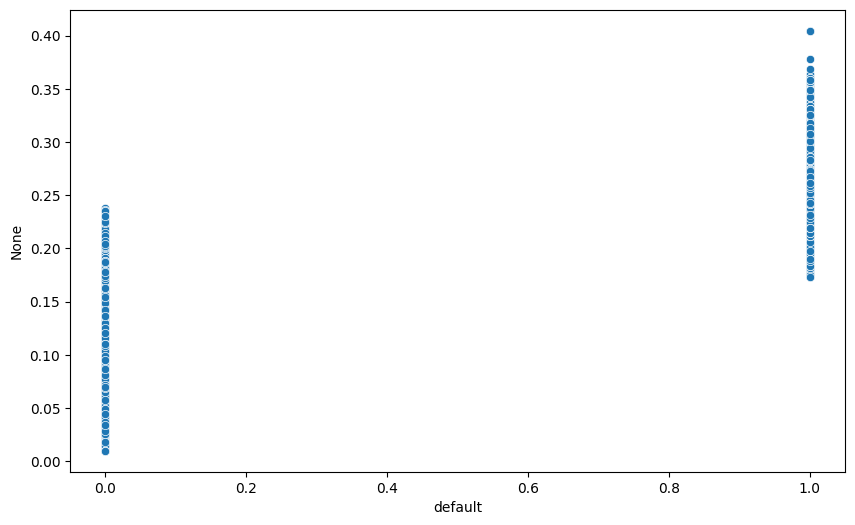

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["default"], y=adf)
plt.show()

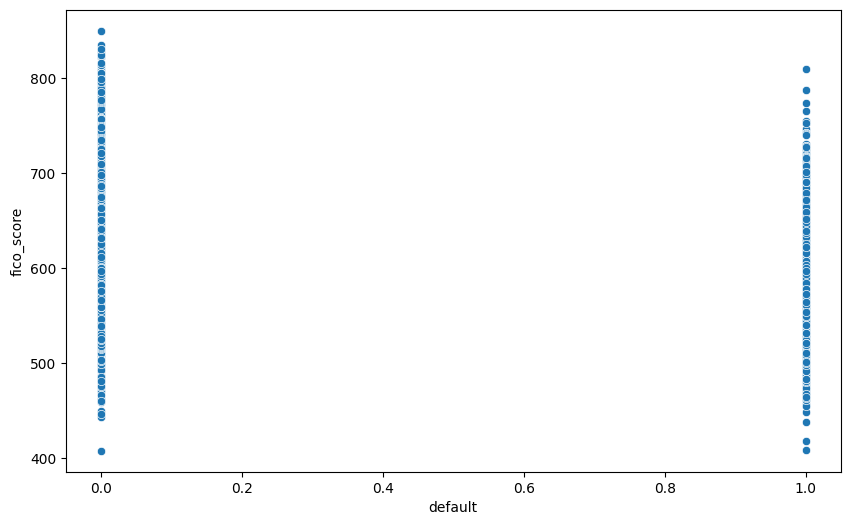

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["default"], y=df["fico_score"])
plt.show()

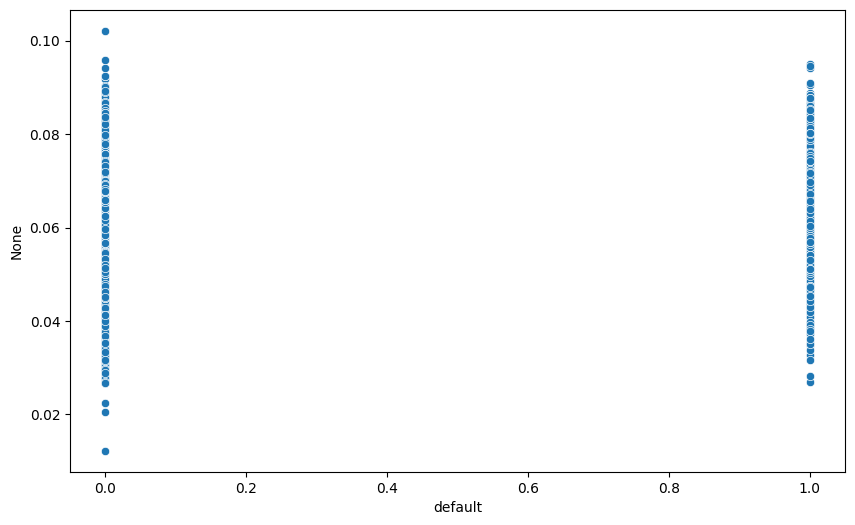

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["default"], y=bdf)
plt.show()

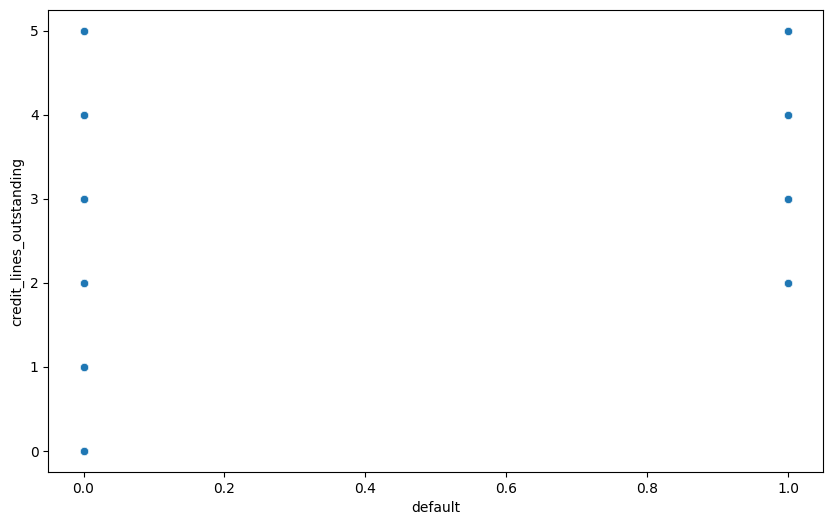

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["default"], y=df["credit_lines_outstanding"])
plt.show()

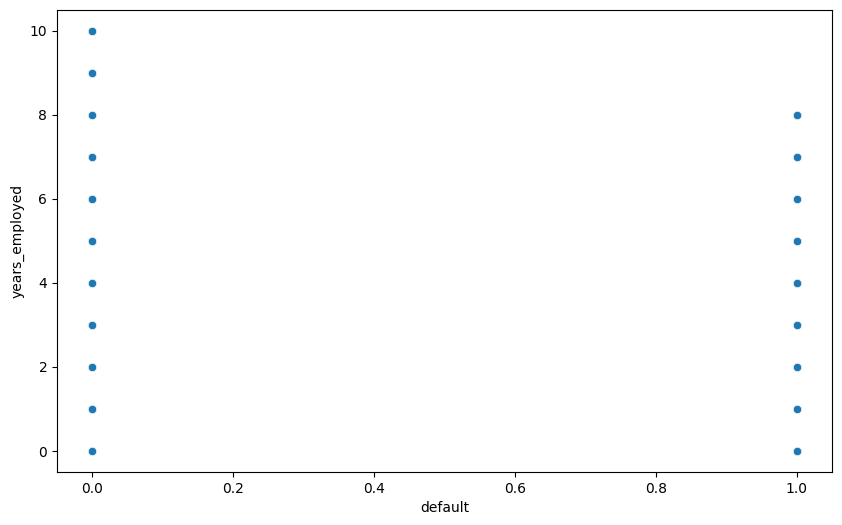

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["default"], y=df["years_employed"])
plt.show()

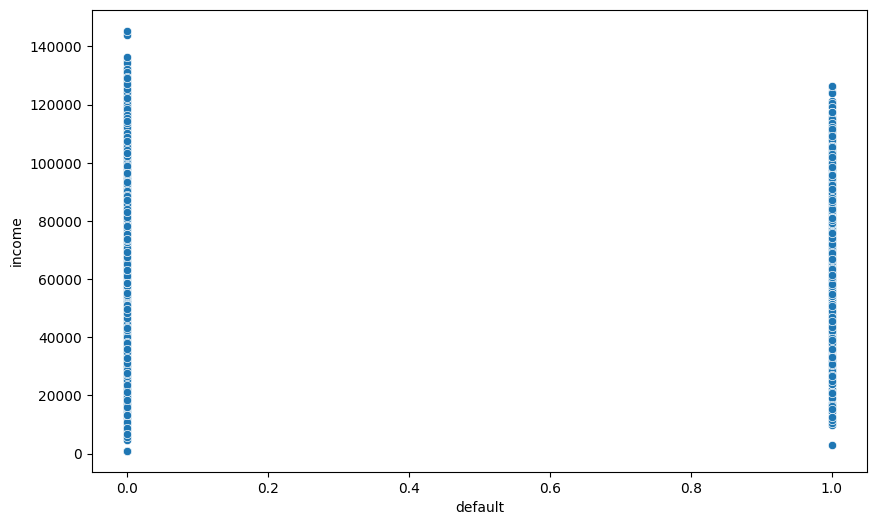

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["default"], y=df["income"])
plt.show()

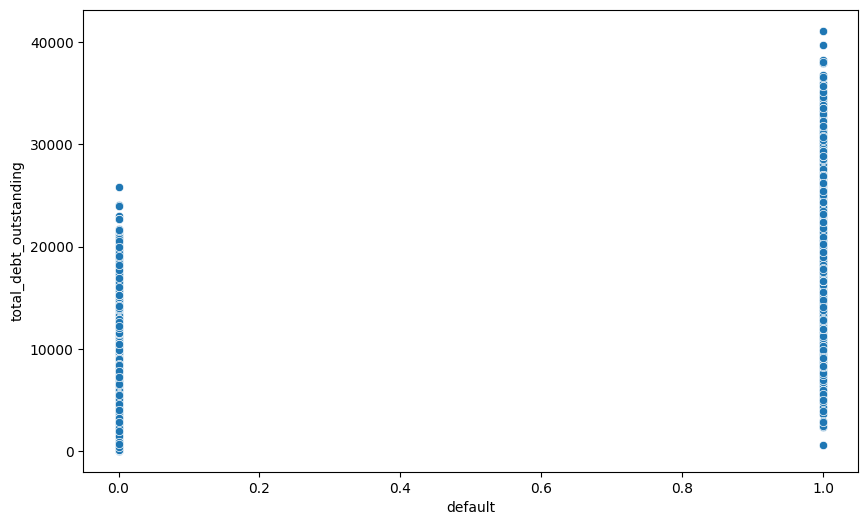

In [ ]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df["default"], y=df["total_debt_outstanding"])
plt.show()

In [ ]:
df["DTI"] = adf

In [ ]:
df = df.drop(["income","customer_id","total_debt_outstanding"],axis=1)

In [76]:
df.loc[df.default == 1]

,credit_lines_outstanding,loan_amt_outstanding,years_employed,fico_score,default,DTI
5866,5,1585.771550,7,659,1,0.227132
5905,5,3997.213649,2,605,1,0.264895
9291,4,941.510646,4,628,1,0.232445
3979,5,5562.131089,4,546,1,0.277048
4355,4,5057.597926,6,629,1,0.201503
...,...,...,...,...,...,...
2558,4,5628.221523,5,659,1,0.231280
6396,5,5042.679355,5,652,1,0.258460
2433,5,4651.928230,3,597,1,0.267545
1685,5,3005.023314,5,622,1,0.261883


In [ ]:
[1,4578.23956,4,650,0.106998]

In [ ]:
index = df.loc[df.loan_amt_outstanding >8500].index

In [ ]:
df = df.drop(index, axis=0)

(array([  34.,  200.,  717., 1618., 1904., 1644., 1019.,  534.,  218.,
          83.]),
 array([  46.7839734 ,  891.81412886, 1736.84428432, 2581.87443978,
        3426.90459524, 4271.9347507 , 5116.96490616, 5961.99506162,
        6807.02521708, 7652.05537254, 8497.085528  ]),
 <BarContainer object of 10 artists>)

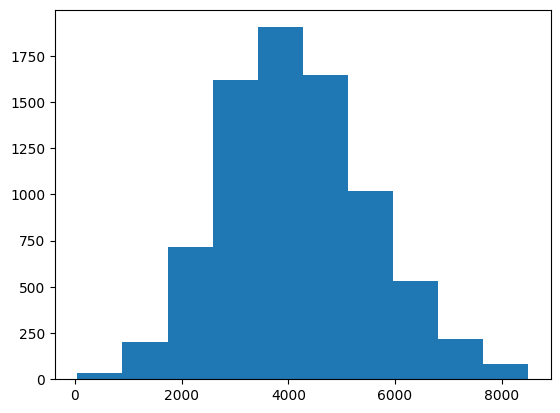

In [ ]:
plt.hist(df["loan_amt_outstanding"])

(array([   8.,   93.,  345., 1065., 1964., 2278., 1495.,  578.,  126.,
          19.]),
 array([408. , 452.2, 496.4, 540.6, 584.8, 629. , 673.2, 717.4, 761.6,
        805.8, 850. ]),
 <BarContainer object of 10 artists>)

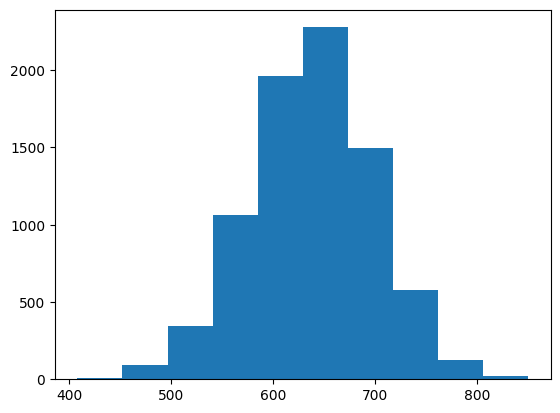

In [ ]:
plt.hist(df["fico_score"])

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

# fit once on training data only
scaler.fit(df_train[['loan_amt_outstanding', 'fico_score']])

# transform and save both
df_train[['loan_amt_outstanding', 'fico_score']] = scaler.transform(df_train[['loan_amt_outstanding', 'fico_score']])
df_test[['loan_amt_outstanding', 'fico_score']]  = scaler.transform(df_test[['loan_amt_outstanding', 'fico_score']])

In [ ]:
X_train = df_train.drop("default", axis=1)
y_train = df_train["default"]
X_test = df_test.drop("default", axis=1)
y_test = df_test["default"]

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
lr = LogisticRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9937304075235109
[[1276    7]
 [   3  309]]
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1283
           1       0.98      0.99      0.98       312

    accuracy                           0.99      1595
   macro avg       0.99      0.99      0.99      1595
weighted avg       0.99      0.99      0.99      1595



In [ ]:
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
print(accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9962382445141066
[[1279    4]
 [   2  310]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1283
           1       0.99      0.99      0.99       312

    accuracy                           1.00      1595
   macro avg       0.99      1.00      0.99      1595
weighted avg       1.00      1.00      1.00      1595



In [ ]:
X_train

,credit_lines_outstanding,loan_amt_outstanding,years_employed,fico_score,DTI
4884,0,0.702760,4,0.368778,0.044825
9254,0,0.350111,5,0.687783,0.066971
981,2,0.380037,6,0.649321,0.149262
9374,0,0.331935,4,0.642534,0.058412
973,1,0.395464,5,0.651584,0.125498
...,...,...,...,...,...
9682,0,0.591665,3,0.454751,0.058487
8491,0,0.270484,5,0.518100,0.066349
2543,0,0.508373,3,0.332579,0.044743
2491,1,0.490427,6,0.454751,0.072231


In [ ]:
td["DTI"] = td["total_debt_outstanding"]/td["income"]
td = td.drop(["income","customer_id","total_debt_outstanding"],axis=1)

In [ ]:
td[['loan_amt_outstanding', 'fico_score']] = scaler.transform(td[['loan_amt_outstanding', 'fico_score']])

In [75]:
td

,credit_lines_outstanding,loan_amt_outstanding,years_employed,fico_score,default,DTI
6252,2,0.418690,8,0.418552,0,0.107058
4684,3,0.683316,6,0.511312,0,0.203217
1731,5,0.626772,4,0.450226,1,0.354730
4742,0,0.168217,5,0.481900,0,0.047843
4521,1,0.411014,6,0.547511,0,0.129249
...,...,...,...,...,...,...
6412,1,0.846783,5,0.572398,0,0.106203
8285,0,0.806625,4,0.400452,0,0.057947
7853,2,0.472403,4,0.554299,0,0.129680
1095,1,0.126837,6,0.861991,0,0.107110


In [ ]:
td_X = td.drop("default", axis=1)
td_y = td["default"]

In [ ]:
td_pred = lr.predict(td_X)
print(accuracy_score(td_y, td_pred))
print(confusion_matrix(td_y, td_pred))
print(classification_report(td_y, td_pred))

0.9945
[[1648    4]
 [   7  341]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1652
           1       0.99      0.98      0.98       348

    accuracy                           0.99      2000
   macro avg       0.99      0.99      0.99      2000
weighted avg       0.99      0.99      0.99      2000



In [ ]:
td_pred = rf.predict(td_X)
print(accuracy_score(td_y, td_pred))
print(confusion_matrix(td_y, td_pred))
print(classification_report(td_y, td_pred))

0.9965
[[1650    2]
 [   5  343]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1652
           1       0.99      0.99      0.99       348

    accuracy                           1.00      2000
   macro avg       1.00      0.99      0.99      2000
weighted avg       1.00      1.00      1.00      2000



In [44]:
td_pre_probab = rf.predict_proba(td_X)[:,1]
td_pre_probab

array([0.  , 0.1 , 1.  , ..., 0.  , 0.  , 0.08])

# Default predection model is created
# Now to access the loss

In [72]:
def expected_loss(credit_lines_outstanding,EAD,years_employed,fico_score,DTI,recovery_rate=0.10):
  clo = credit_lines_outstanding
  ye = years_employed
  fs = fico_score

  # Reshape EAD and fico_score into a single sample with two features for scaler.transform
  scaled_values = scaler.transform(np.array([[EAD, fs]]))
  ScalEAD = scaled_values[0, 0]
  ScalFico = scaled_values[0, 1]

  # Create a 2D array for the random forest predict_proba method
  # The order of features should match the training data: credit_lines_outstanding, loan_amt_outstanding, years_employed, fico_score, DTI
  input_features = np.array([[clo, ScalEAD, ye, ScalFico, DTI]])

  PD = rf.predict_proba(input_features)[0,1]

  LGD = 1 - recovery_rate  # 90% of loan is lost if they default
  return PD * LGD * EAD

# Eg of no default loss

In [73]:
expected_loss(1,4578.23956,4,650,0.106998,recovery_rate=0.10)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


np.float64(0.0)

# Eg of default loss

In [77]:
expected_loss(5,1585.771550,7,659,0.227132,recovery_rate=0.10)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


np.float64(1156.02745995)